# 使用FlashTorch套件，觀察梯度對辨識的幫助

## 載入相關套件

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torchvision.models as models
from flashtorch.saliency import Backprop
import flashtorch.saliency.backprop as _ft_backprop
from flashtorch.utils import apply_transforms, load_image

In [2]:
# 修正 flashtorch 在新版 PyTorch 下的錯誤：
# RuntimeError: Output 0 of Unbind is a view and is being modified inplace.
# 原因是 denormalize() 對 unbind 產生的 view 做 in-place 運算，新版 PyTorch 不允許，改為 out-of-place 寫法

def _denormalize_fixed(tensor):
    means = [0.485, 0.456, 0.406]
    stds = [0.229, 0.224, 0.225]
    denormalized = tensor.clone()
    for i, (mean, std) in enumerate(zip(means, stds)):
        denormalized[0, i] = denormalized[0, i] * std + mean
    return denormalized

_ft_backprop.denormalize = _denormalize_fixed

## 載入圖檔

In [3]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

(np.float64(-0.5), np.float64(479.5), np.float64(319.5), np.float64(-0.5))

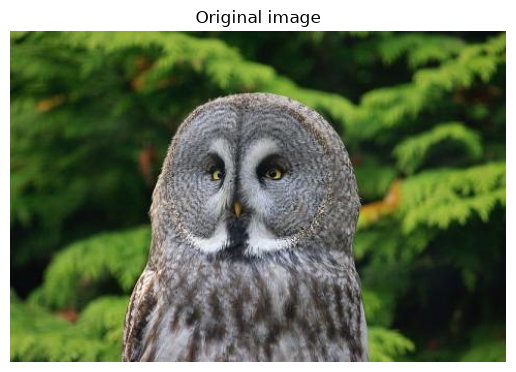

In [4]:
image = load_image(base_path / 'images_test/owl.jpg')

plt.imshow(image)
plt.title('Original image')
plt.axis('off')

## 載入預先訓練的模型 AlexNet

In [5]:
model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

## 建立反向傳導的物件

In [6]:
backprop = Backprop(model)

## 觀察顯著地圖(Saliency map)

/Users/rikenmi/Work/study/python/PyTorch_Book/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1869: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


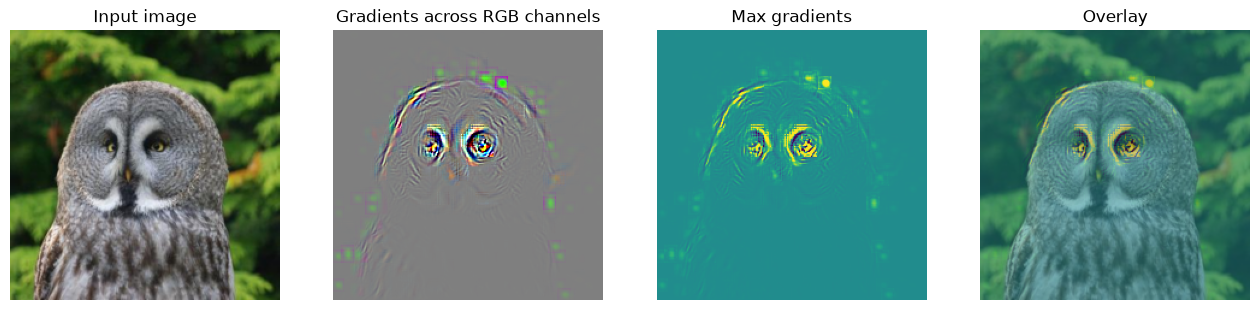

In [7]:
# 將圖像轉換為張量
owl = apply_transforms(image)

# 貓頭鷹(Owl)在 ImageNet 的類別代碼為 24
target_class = 24

# 視覺化
backprop.visualize(owl, target_class, guided=True)

## 其他圖像

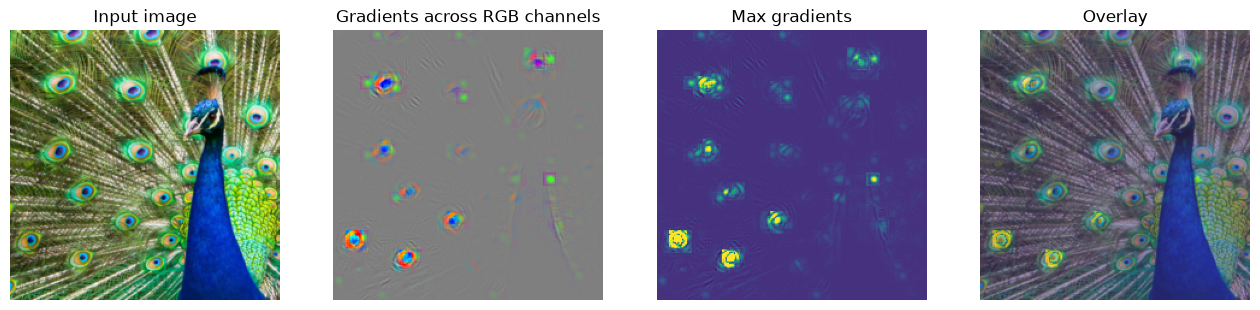

In [8]:
peacock = apply_transforms(load_image(base_path / 'images_test/peacock.jpg'))
backprop.visualize(peacock, 84, guided=True)

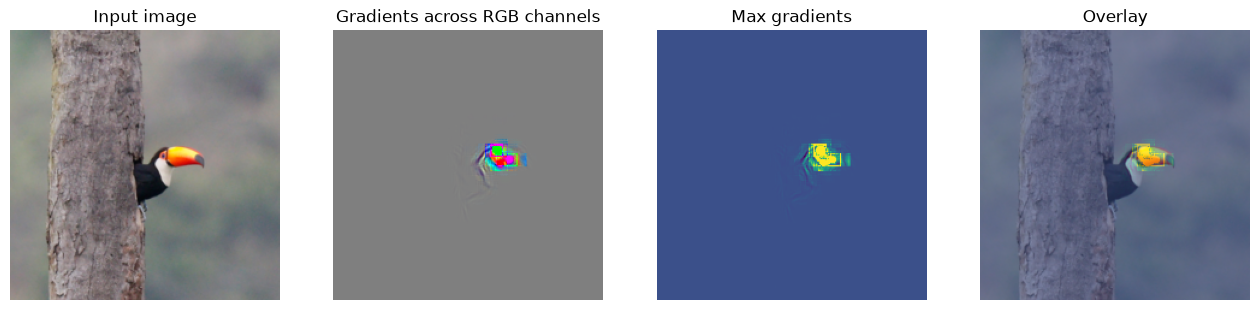

In [9]:
toucan = apply_transforms(load_image(base_path / 'images_test/toucan.jpg'))
backprop.visualize(toucan, 96, guided=True)